In [12]:
import pandas as pd
import os 

from dotenv import load_dotenv
load_dotenv()

from snowflake.snowpark import Session
%matplotlib inline

conn = {
    "account": os.getenv("account"),
    "user": os.getenv("user"),
    "password": os.getenv("password"),
    "role": "ACCOUNTADMIN",
    "warehouse": "COMPUTE_WH",
    "database": "LH_NAUTICALS"
}

session = Session.builder.configs(conn).create()


df_snowpark = session.table("LH_NAUTICALS.QUESTAO1.VENDAS_2023_2024")
df_pandas = df_snowpark.to_pandas()

## Análise de Outliers em "total", Qualidade dos Dados e Preparação do Dataset

In [ ]:

print("Shape do dataset:", df_pandas.shape)
print("\nTipos de dados:")
print(df_pandas.dtypes)
print("\nPrimeiras linhas:")
print(df_pandas.head())
print("\nEstatísticas descritivas:")
print(df_pandas.describe())

Shape do dataset: (9901, 6)

Tipos de dados:
ID            float64
ID_CLIENT     float64
ID_PRODUCT    float64
QTD           float64
TOTAL         float64
SALE_DATE      object
dtype: object

Primeiras linhas:
    ID  ID_CLIENT  ID_PRODUCT   QTD     TOTAL   SALE_DATE
0  0.0       42.0       105.0  11.0    3405.0  2023-09-10
1  1.0        3.0       136.0   9.0   16873.9  15-09-2024
2  2.0       25.0       139.0   7.0    9475.3  2024-08-13
3  4.0       20.0        23.0   5.0   55893.0  2023-02-03
4  5.0        8.0        57.0   4.0  451403.9  2024-02-12

Estatísticas descritivas:
                ID    ID_CLIENT   ID_PRODUCT          QTD         TOTAL
count  9895.000000  9895.000000  9895.000000  9895.000000  9.895000e+03
mean   5000.755533    24.874583    75.255786     8.015260  2.637978e+05
std    2887.000000    14.177715    43.533397     4.301723  3.900072e+05
min       0.000000     1.000000     1.000000     1.000000  2.945000e+02
25%    2501.500000    13.000000    37.000000     4.0000

In [ ]:

print("Valores nulos por coluna:")
print(df_pandas.isnull().sum())


print("\nValores únicos em cada coluna:")
for col in df_pandas.columns:
    print(f"{col}: {df_pandas[col].nunique()} valores únicos")


print(f"\nValores em 'TOTAL' <= 0: {len(df_pandas[df_pandas['TOTAL'] <= 0])}")


df_pandas['SALE_DATE'] = pd.to_datetime(df_pandas['SALE_DATE'], errors='coerce')
print(f"\nDatas inválidas em 'SALE_DATE': {df_pandas['SALE_DATE'].isnull().sum()}")

Valores nulos por coluna:
ID            6
ID_CLIENT     6
ID_PRODUCT    6
QTD           6
TOTAL         6
SALE_DATE     6
dtype: int64

Valores únicos em cada coluna:
ID: 9895 valores únicos
ID_CLIENT: 49 valores únicos
ID_PRODUCT: 150 valores únicos
QTD: 15 valores únicos
TOTAL: 3980 valores únicos
SALE_DATE: 1446 valores únicos

Valores em 'TOTAL' <= 0: 0

Datas inválidas em 'SALE_DATE': 4988


<Axes: >

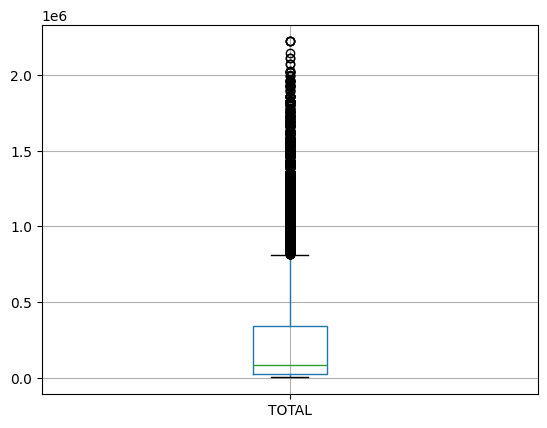

In [22]:
df_pandas.boxplot(column='TOTAL')


<Axes: >

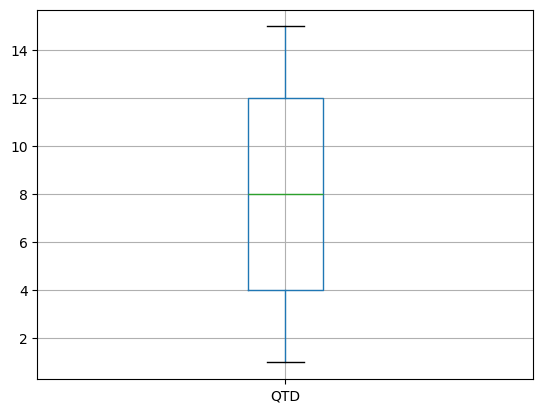

In [21]:
df_pandas.boxplot(column='QTD')

In [ ]:

nulls = df_pandas.isnull().sum().sum()
outliers_count = len(outliers)
invalid_dates = df_pandas['SALE_DATE'].isnull().sum()
negative_totals = len(df_pandas[df_pandas['TOTAL'] <= 0])

if nulls == 0 and outliers_count == 0 and invalid_dates == 0 and negative_totals == 0:
    print("O dataset parece estar pronto para análises, sem valores nulos, outliers, datas inválidas ou totais negativos.")
else:
    print("O dataset pode precisar de tratamento prévio:")
    if nulls > 0:
        print(f"- Há {nulls} valores nulos.")
    if outliers_count > 0:
        print(f"- Há {outliers_count} possíveis outliers em 'TOTAL'.")
    if invalid_dates > 0:
        print(f"- Há {invalid_dates} datas inválidas.")
    if negative_totals > 0:
        print(f"- Há {negative_totals} valores de 'TOTAL' negativos ou zero.")

O dataset pode precisar de tratamento prévio:
- Há 5018 valores nulos.
- Há 1018 possíveis outliers em 'TOTAL'.
- Há 4988 datas inválidas.
